# 17 — Ramo P riaddestrato: sovrapposizione delle finestre e rimozione dei canali di intensità

**Domanda.** Riaddestrando il ramo P (architettura e preprocessing del notebook 06.1, variante D) cambiando
(i) il passo delle finestre e/o (ii) i canali di intensità in ingresso, l'EER sul dev 2019 scende rispetto alla
configurazione attuale?

| Config. | Finestre (lunghezza/passo) | Canali | Canali tolti |
|---|---|---|---|
| **C0** (controllo) | 200/200 ms | 16 | nessuno |
| C1  | 200/200 ms | 14 | `intensity_mean`, `d_intensity_mean` |
| C1b | 200/200 ms | 12 | + `intensity_std`, `d_intensity_std` |
| C2  | 200/150 ms | 16 | nessuno |
| C3  | 200/150 ms | 14 | come C1 |
| C3b | 200/150 ms | 12 | come C1b |

**Protocollo.** Identico al notebook 06.1 (architettura, preprocessing clip 0,1–99,9 + min-max sul train,
Adam lr 1e-3, batch 32, BCE con `pos_weight`, massimo 40 epoche, pazienza 10, `ReduceLROnPlateau` fattore 0,5
pazienza 3, 5 semi) con **una sola differenza voluta**: early stopping, scelta del checkpoint e scheduler usano
l'**EER ufficiale sul dev** invece della loss del dev. Per questo il controllo è **C0**, cioè la configurazione
attuale riaddestrata con la stessa procedura, e non il P del notebook 06.1.

Le delta si calcolano come nel 06.1 sulle 8 caratteristiche (maschera delle finestre sonore calcolata sulle 8);
i canali vengono tolti **dopo**, così la maschera e le altre delta restano identiche fra le configurazioni.

**Regola di decisione (fissata prima dell'esecuzione).** Vince la configurazione con l'EER medio sui 5 semi
più basso tra quelle con EER medio **inferiore a C0**. Se nessuna scende sotto C0 si tiene il ramo P attuale.
Il confronto con il P del notebook 06.1 (variante D, media 11,15%) e i bootstrap appaiati per seme sono
riportati come informazione, non entrano nella regola.

**Fasi** (`FASE`, combinabili con `+`):
1. `verifica` — riestrae 300 file del train con passo 200 ms e controlla che coincidano con `standard_train.npz`
   (garantisce che l'estrazione con passo 150 ms usi esattamente la pipeline del notebook 04);
2. `estrazione` — train e dev 2019 con passo 150 ms (circa 1 h su 4 core, stima);
3. `addestramento` — controllo di riproduzione del 06.1 (D, seme 0, early stopping sulla loss: atteso 11,77%)
   e poi 6 configurazioni × 5 semi;
4. `riepilogo` — tabelle, regola di decisione, figura.


In [1]:
import os, sys, re, json, time, copy, shutil, hashlib, importlib.util, urllib.request, subprocess
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence, PackedSequence
try:
    import parselmouth
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "praat-parselmouth==0.4.7"], check=True)
    import parselmouth
from parselmouth.praat import call

# ------------------------------- percorsi -----------------------------------
FASE = os.environ.get("FASE", "verifica+estrazione+addestramento+riepilogo")
INPUT_ROOT = Path(os.environ.get("INPUT_ROOT", "/kaggle/input"))
BASE = INPUT_ROOT / "datasets/angelopaldino"
LA_ROOT = BASE / "asvspoof2019-train-dev/LA"                    # audio + protocolli 2019 LA
FEAT_DIR = BASE / "prosody-features/prosody_features"           # output del notebook 04 (passo 200 ms)
PREPROC_P_ATTUALE = BASE / "models/Modelli/preproc_prosody.json"  # solo per un controllo informativo
OUT_DIR = Path(os.environ.get("OUT_DIR", "/kaggle/working/p_riaddestramento"))
RIPRESA = os.environ.get("RIPRESA", "")   # cartella 'p_riaddestramento' di una versione precedente (in /kaggle/input)

FEAT150_DIR = OUT_DIR / "prosodia_h150"
PART_DIR = FEAT150_DIR / "_parti"
MOD_DIR = OUT_DIR / "modelli"
SCO_DIR = OUT_DIR / "punteggi_dev"
for d in (OUT_DIR, FEAT150_DIR, MOD_DIR, SCO_DIR):
    d.mkdir(parents=True, exist_ok=True)
_t = OUT_DIR / ".test_scrittura"; _t.write_text("ok"); _t.unlink()      # OUT_DIR deve essere scrivibile

# --------------------- estrazione: parametri del notebook 04 ----------------
PITCH_FLOOR, PITCH_CEILING = 75.0, 500.0
MAX_CANDIDATES, VERY_ACCURATE, VOICING_THRESHOLD, TIME_STEP = 15, "no", 0.45, 0.0
PERIOD_FLOOR, PERIOD_CEILING = 0.8 / PITCH_CEILING, 1.25 / PITCH_FLOOR
MAX_PERIOD_FACTOR, MAX_AMPLITUDE_FACTOR = 1.3, 1.6
HNR_TIME_STEP, HNR_SILENCE, HNR_PERIODS = 0.01, 0.1, 1.0
CFG_STANDARD = {"silence_threshold": 0.03, "octave_cost": 0.01, "octave_jump_cost": 0.35, "voiced_unvoiced_cost": 0.14}
FEATURES = ["f0_mean", "f0_std", "jitter_local", "shimmer_local",
            "hnr_mean", "hnr_std", "intensity_mean", "intensity_std"]
FINESTRE = {"h200": (0.2, 0.2), "h150": (0.2, 0.15)}      # (lunghezza, passo) in secondi
EXPECTED_ROWS = {"train": 25380, "dev": 24844}
N_WORKERS = os.cpu_count() or 1
CHUNK = int(os.environ.get("CHUNK", 1000))
N_VERIFICA = int(os.environ.get("N_VERIFICA", 300))

# --------------------- addestramento: parametri del notebook 06.1 -----------
CONFIGURAZIONI = {
    "C0":  {"finestre": "h200", "togli": []},
    "C1":  {"finestre": "h200", "togli": ["intensity_mean"]},
    "C1b": {"finestre": "h200", "togli": ["intensity_mean", "intensity_std"]},
    "C2":  {"finestre": "h150", "togli": []},
    "C3":  {"finestre": "h150", "togli": ["intensity_mean"]},
    "C3b": {"finestre": "h150", "togli": ["intensity_mean", "intensity_std"]},
}
RIFERIMENTO = "C0"
SEMI = [int(s) for s in os.environ.get("SEMI", "0,1,2,3,4").split(",")]
MAX_EPOCHS = int(os.environ.get("MAX_EPOCHS", 40))
PATIENCE = int(os.environ.get("PATIENCE", 10))
LR_FACTOR, LR_PATIENCE = 0.5, 3
BATCH_SIZE, LR, DROPOUT = 32, 1e-3, 0.2
CLIP_PCT = (0.1, 99.9)
N_BOOT = int(os.environ.get("N_BOOT", 1000))
# Risultati del notebook 06.1, variante D (early stopping sulla loss del dev), EER dev in %
RIF_06 = {0: 11.77, 1: 11.77, 2: 9.93, 3: 10.84, 4: 11.46}
TOLL_RIPRODUZIONE = 0.3     # punti: controllo NON bloccante sul seme 0

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
if DEVICE == "cuda":
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True

if RIPRESA:
    src = Path(RIPRESA)
    assert src.exists(), f"RIPRESA non esiste: {src}"
    assert any((src / p).exists() for p in ("prosodia_h150", "modelli", "risultati.csv")), \
        f"{src} non sembra la cartella 'p_riaddestramento' di una versione precedente"
    shutil.copytree(src, OUT_DIR, dirs_exist_ok=True)
    print("ripresa da", src)
print(f"FASE = {FASE} | parselmouth {parselmouth.__version__} | Praat {parselmouth.PRAAT_VERSION} | "
      f"torch {torch.__version__} | device {DEVICE} | core {N_WORKERS}")

FASE = verifica+estrazione+addestramento+riepilogo | parselmouth 0.4.7 | Praat 6.1.38 | torch 2.10.0+cu128 | device cuda | core 4


In [2]:
# Metrica ufficiale ASVspoof 2021, identica ai notebook precedenti.
EVAL_METRICS_URL = "https://raw.githubusercontent.com/asvspoof-challenge/2021/main/eval-package/eval_metrics.py"
EVAL_METRICS_PATH = OUT_DIR / "eval_metrics.py"
if not EVAL_METRICS_PATH.exists():
    urllib.request.urlretrieve(EVAL_METRICS_URL, EVAL_METRICS_PATH)
spec = importlib.util.spec_from_file_location("asvspoof_eval_metrics", EVAL_METRICS_PATH)
asv_metrics = importlib.util.module_from_spec(spec); spec.loader.exec_module(asv_metrics)
EVAL_METRICS_SHA256 = hashlib.sha256(EVAL_METRICS_PATH.read_bytes()).hexdigest()
assert EVAL_METRICS_SHA256.startswith("70c5d2fe8fab6654"), EVAL_METRICS_SHA256[:16]
print("eval_metrics.py | sha256", EVAL_METRICS_SHA256[:16], "...")

def compute_eer(y, s):
    """EER ufficiale ASVspoof: y = 1 bona fide; punteggio alto = bona fide."""
    y, s = np.asarray(y), np.asarray(s, dtype=np.float64)
    return float(asv_metrics.compute_eer(s[y == 1], s[y == 0])[0])

assert compute_eer([1, 1, 0, 0], [2.0, 3.0, 0.0, 1.0]) == 0.0
assert compute_eer([1, 1, 0, 0], [0.0, 1.0, 2.0, 3.0]) == 1.0

eval_metrics.py | sha256 70c5d2fe8fab6654 ...


In [3]:
def find_la_root(root):
    for dirpath, dirnames, _ in os.walk(root):
        dirnames[:] = [d for d in dirnames if d != "flac"]
        if "ASVspoof2019_LA_cm_protocols" in dirnames:
            return Path(dirpath)
    raise RuntimeError(f"Cartella con ASVspoof2019_LA_cm_protocols non trovata sotto {root}")

if not (LA_ROOT / "ASVspoof2019_LA_cm_protocols").is_dir():
    LA_ROOT = find_la_root(BASE / "asvspoof2019-train-dev")
assert (FEAT_DIR / "standard_train.npz").exists() and (FEAT_DIR / "index.csv").exists(), FEAT_DIR

PATTERNS = {"train": r"cm[._]train[._]trn", "dev": r"cm[._]dev[._]trl"}
frames = []
for split, pat in PATTERNS.items():
    f = [p for p in (LA_ROOT / "ASVspoof2019_LA_cm_protocols").iterdir() if re.search(pat, p.name)]
    assert len(f) == 1, f
    df = pd.read_csv(f[0], sep=r"\s+", header=None, dtype=str, keep_default_na=False, engine="python",
                     names=["speaker", "utt_id", "unused", "attack", "label"])
    df["split"] = split
    df["path"] = [str(LA_ROOT / f"ASVspoof2019_LA_{split}" / "flac" / f"{u}.flac") for u in df["utt_id"]]
    if len(df) != EXPECTED_ROWS[split]:
        print(f"ATTENZIONE {split}: {len(df)} righe, attese {EXPECTED_ROWS[split]}")
    frames.append(df)
files = pd.concat(frames, ignore_index=True).drop(columns="unused").set_index("utt_id")

INDEX = pd.read_csv(FEAT_DIR / "index.csv").set_index("utt_id")
UTT = {s: np.load(FEAT_DIR / f"standard_{s}.npz", allow_pickle=True)["utt_id"] for s in ("train", "dev")}
for s in ("train", "dev"):
    assert set(UTT[s]) == set(files.index[files["split"] == s]), f"{s}: utt_id di standard_{s}.npz diversi dal protocollo"
print({s: len(u) for s, u in UTT.items()}, "| LA_ROOT", LA_ROOT)

{'train': 25380, 'dev': 24844} | LA_ROOT /kaggle/input/datasets/angelopaldino/asvspoof2019-train-dev/LA


In [4]:
def make_windows(duration, w, hop):
    starts = np.arange(0.0, duration, hop)
    ends = np.minimum(starts + w, duration)
    keep = (ends - starts) >= w / 2
    return starts[keep], ends[keep]

_s, _e = make_windows(0.95, 0.2, 0.2)
assert np.allclose(_s, [0, .2, .4, .6, .8]) and np.allclose(_e, [.2, .4, .6, .8, .95])
_s, _e = make_windows(0.95, 0.2, 0.15)      # starts 0..0,9; la coda 0,9-0,95 (50 ms) viene scartata
assert np.allclose(_s, [0, .15, .3, .45, .6, .75]) and np.allclose(_e[-1], 0.95)


def window_features(snd, pp, ht, hv, it, iv, a, b, pt, f0):
    f0w = f0[(pt >= a) & (pt < b)]
    f0w = f0w[f0w > 0]
    if len(f0w) == 0:
        return np.zeros(len(FEATURES))
    out = np.full(len(FEATURES), np.nan)
    out[0] = f0w.mean()
    out[1] = f0w.std() if len(f0w) >= 2 else np.nan
    try:
        out[2] = call(pp, "Get jitter (local)", a, b, PERIOD_FLOOR, PERIOD_CEILING, MAX_PERIOD_FACTOR)
    except Exception:
        pass
    try:
        out[3] = call([snd, pp], "Get shimmer (local)", a, b, PERIOD_FLOOR, PERIOD_CEILING,
                      MAX_PERIOD_FACTOR, MAX_AMPLITUDE_FACTOR)
    except Exception:
        pass
    hw = hv[(ht >= a) & (ht < b)]; hw = hw[hw > -100]
    if len(hw):
        out[4] = hw.mean(); out[5] = hw.std() if len(hw) >= 2 else np.nan
    iw = iv[(it >= a) & (it < b)]; iw = iw[np.isfinite(iw)]
    if len(iw):
        out[6] = iw.mean(); out[7] = iw.std() if len(iw) >= 2 else np.nan
    return np.nan_to_num(out, nan=0.0)


def process_file(path, finestre=("h200", "h150")):
    """{nome_finestre: X} per un file, configurazione Praat 'standard'. Errori restituiti come stringa."""
    try:
        snd = parselmouth.Sound(path)
        harm = call(snd, "To Harmonicity (cc)", HNR_TIME_STEP, PITCH_FLOOR, HNR_SILENCE, HNR_PERIODS)
        inten = snd.to_intensity(minimum_pitch=PITCH_FLOOR)
        ht, hv = np.asarray(harm.xs()), np.asarray(harm.values[0])
        it, iv = np.asarray(inten.xs()), np.asarray(inten.values[0])
        c = CFG_STANDARD
        pitch = call(snd, "To Pitch (cc)", TIME_STEP, PITCH_FLOOR, MAX_CANDIDATES, VERY_ACCURATE,
                     c["silence_threshold"], VOICING_THRESHOLD, c["octave_cost"],
                     c["octave_jump_cost"], c["voiced_unvoiced_cost"], PITCH_CEILING)
        pp = call([snd, pitch], "To PointProcess (cc)")
        pt, f0 = np.asarray(pitch.xs()), np.asarray(pitch.selected_array["frequency"])
        out = {}
        for nome in finestre:
            w, hop = FINESTRE[nome]
            starts, ends = make_windows(snd.duration, w, hop)
            X = np.zeros((max(len(starts), 1), len(FEATURES)), dtype=np.float32)
            for i, (a, b) in enumerate(zip(starts, ends)):
                X[i] = window_features(snd, pp, ht, hv, it, iv, a, b, pt, f0)
            out[nome] = X
        return out, snd.duration, ""
    except Exception as e:
        return None, np.nan, repr(e)


def process_h200(path):
    return process_file(path, ("h200",))


def salva_npz_atomico(path, **arrays):
    tmp = path.with_name(path.name + ".tmp")
    with open(tmp, "wb") as fh:
        np.savez(fh, **arrays)
    os.replace(tmp, path)

In [5]:
F_VERIFICA = OUT_DIR / "verifica.json"
if "verifica" in FASE and not F_VERIFICA.exists():
    assert (parselmouth.__version__, parselmouth.PRAAT_VERSION) == ("0.4.7", "6.1.38"), \
        "versione di parselmouth/Praat diversa da quella del notebook 04: le feature non sarebbero confrontabili"
    z = np.load(FEAT_DIR / "standard_train.npz", allow_pickle=True)
    X_old, off_old, utt_old = z["X"], z["offsets"], z["utt_id"]
    pos = {u: i for i, u in enumerate(utt_old)}
    camp = np.random.default_rng(0).choice(utt_old, size=min(N_VERIFICA, len(utt_old)), replace=False)
    t0 = time.perf_counter()
    with ProcessPoolExecutor(max_workers=N_WORKERS) as ex:
        res = list(ex.map(process_h200, files.loc[camp, "path"], chunksize=4))
    dt = time.perf_counter() - t0
    n_ok_len, n_identici, max_diff = 0, 0, 0.0
    for u, (out, _, err) in zip(camp, res):
        assert not err, (u, err)
        old = X_old[off_old[pos[u]]:off_old[pos[u] + 1]]
        new = out["h200"]
        if old.shape == new.shape:
            n_ok_len += 1
            n_identici += int(np.array_equal(old, new))
            max_diff = max(max_diff, float(np.abs(old - new).max()))
    verifica = {"n_file": len(camp), "stesso_numero_finestre": n_ok_len, "identici": n_identici,
                "max_diff_assoluta": max_diff, "secondi": dt,
                "stima_estrazione_h150_min": dt / len(camp) * sum(len(u) for u in UTT.values()) * 1.35 / 60}
    print(json.dumps(verifica, indent=1))
    assert n_ok_len == len(camp), "numero di finestre diverso dal notebook 04: estrazione NON equivalente"
    assert n_identici >= 0.99 * len(camp), "valori diversi dal notebook 04 in più dell'1% dei file"
    F_VERIFICA.write_text(json.dumps(verifica, indent=1))
    print(f"verifica superata. Stima dell'estrazione con passo 150 ms (train + dev): "
          f"~{verifica['stima_estrazione_h150_min']:.0f} min")
elif F_VERIFICA.exists():
    print("verifica già superata:", F_VERIFICA.read_text())

{
 "n_file": 300,
 "stesso_numero_finestre": 300,
 "identici": 300,
 "max_diff_assoluta": 0.0,
 "secondi": 18.089365464000025,
 "stima_estrazione_h150_min": 68.13902182979531
}
verifica superata. Stima dell'estrazione con passo 150 ms (train + dev): ~68 min


In [6]:
def finale_h150(split):
    return FEAT150_DIR / f"standard_{split}.npz"

if "estrazione" in FASE:
    assert F_VERIFICA.exists(), "esegui prima la fase 'verifica'"
    PART_DIR.mkdir(parents=True, exist_ok=True)
    t_start = time.perf_counter()
    righe_indice = []
    for split in ("train", "dev"):
        if finale_h150(split).exists():
            print(f"{split}: già estratto"); continue
        utt = UTT[split]
        n_chunks = (len(utt) + CHUNK - 1) // CHUNK
        for k in range(n_chunks):
            fp = PART_DIR / f"{split}_{k:05d}.npz"
            if fp.exists():
                continue
            blocco = utt[k * CHUNK:(k + 1) * CHUNK]
            t0 = time.perf_counter()
            with ProcessPoolExecutor(max_workers=N_WORKERS) as ex:
                res = list(ex.map(process_file, files.loc[blocco, "path"], [("h150",)] * len(blocco), chunksize=8))
            arr = np.empty(len(res), dtype=object)
            arr[:] = [r[0]["h150"] if r[0] else np.zeros((1, len(FEATURES)), np.float32) for r in res]
            salva_npz_atomico(fp, utt_id=blocco, X=arr, duration=np.array([r[1] for r in res]),
                              error=np.array([r[2] for r in res]))
            dt = time.perf_counter() - t0
            print(f"{split} blocco {k + 1}/{n_chunks}: {dt:.0f} s (residuo ~{dt * (n_chunks - k - 1) / 60:.0f} min)")
        zs = [np.load(PART_DIR / f"{split}_{k:05d}.npz", allow_pickle=True) for k in range(n_chunks)]
        u_all = np.concatenate([z["utt_id"] for z in zs])
        assert np.array_equal(u_all, utt), "ordine dei file diverso da standard_{split}.npz"
        seqs = [x for z in zs for x in z["X"]]
        lens = np.array([len(x) for x in seqs])
        salva_npz_atomico(finale_h150(split), X=np.concatenate(seqs).astype(np.float32),
                          offsets=np.concatenate([[0], np.cumsum(lens)]).astype(np.int64), utt_id=utt)
        errori = np.concatenate([z["error"] for z in zs])
        righe_indice.append(pd.DataFrame({"utt_id": utt, "split": split, "n_windows": lens,
                                          "duration": np.concatenate([z["duration"] for z in zs]),
                                          "error": errori}))
        print(f"{split}: {len(utt)} file | finestre min {lens.min()}, mediana {np.median(lens):.0f}, "
              f"max {lens.max()} | errori {(errori != '').sum()}")
    if righe_indice:
        f_ind = FEAT150_DIR / "indice_h150.csv"
        vecchio = pd.read_csv(f_ind) if f_ind.exists() else None
        ind = pd.concat(([vecchio] if vecchio is not None else []) + righe_indice).drop_duplicates("utt_id", keep="last")
        ind.to_csv(f_ind, index=False)
        meta = {"finestra_s": FINESTRE["h150"][0], "passo_s": FINESTRE["h150"][1], "praat_config": CFG_STANDARD,
                "features": FEATURES, "praat_version": parselmouth.PRAAT_VERSION,
                "parselmouth_version": parselmouth.__version__,
                "regola_finestre": "make_windows del notebook 04 con passo parametrico; coda < 100 ms scartata",
                "formato": "come notebook 04: X (finestre concatenate, float32), offsets (N+1), utt_id"}
        (FEAT150_DIR / "meta_h150.json").write_text(json.dumps(meta, indent=2))
        if all(finale_h150(s).exists() for s in ("train", "dev")) and (ind["error"].fillna("") == "").all():
            shutil.rmtree(PART_DIR, ignore_errors=True)
    print(f"estrazione: {(time.perf_counter() - t_start) / 60:.1f} min")

train blocco 1/26: 63 s (residuo ~26 min)
train blocco 2/26: 57 s (residuo ~23 min)
train blocco 3/26: 60 s (residuo ~23 min)
train blocco 4/26: 58 s (residuo ~21 min)
train blocco 5/26: 58 s (residuo ~20 min)
train blocco 6/26: 45 s (residuo ~15 min)
train blocco 7/26: 70 s (residuo ~22 min)
train blocco 8/26: 76 s (residuo ~23 min)
train blocco 9/26: 73 s (residuo ~21 min)
train blocco 10/26: 65 s (residuo ~17 min)
train blocco 11/26: 69 s (residuo ~17 min)
train blocco 12/26: 64 s (residuo ~15 min)
train blocco 13/26: 59 s (residuo ~13 min)
train blocco 14/26: 60 s (residuo ~12 min)
train blocco 15/26: 62 s (residuo ~11 min)
train blocco 16/26: 63 s (residuo ~11 min)
train blocco 17/26: 54 s (residuo ~8 min)
train blocco 18/26: 61 s (residuo ~8 min)
train blocco 19/26: 64 s (residuo ~7 min)
train blocco 20/26: 66 s (residuo ~7 min)
train blocco 21/26: 55 s (residuo ~5 min)
train blocco 22/26: 67 s (residuo ~4 min)
train blocco 23/26: 60 s (residuo ~3 min)
train blocco 24/26: 63 s (r

In [7]:
def voiced_mask(x):
    return np.abs(x).sum(1) > 0

def dynamic_features(x):
    v = voiced_mask(x)
    n = len(x)
    d_ok = np.zeros(n, dtype=bool)
    d_ok[1:] = v[1:] & v[:-1]
    d = np.zeros_like(x)
    d[d_ok] = x[d_ok] - x[np.where(d_ok)[0] - 1]
    return d, d_ok

_x = np.array([[180.], [195.], [170.], [0.], [175.], [190.], [185.]], dtype=np.float32)
assert dynamic_features(_x)[0][:, 0].tolist() == [0, 15, -25, 0, 0, 15, -5]

NOMI16 = FEATURES + [f"d_{f}" for f in FEATURES]

def carica_raw(finestre, split):
    path = (FEAT_DIR if finestre == "h200" else FEAT150_DIR) / f"standard_{split}.npz"
    z = np.load(path, allow_pickle=True)
    X, off, utt = z["X"], z["offsets"], z["utt_id"]
    assert np.array_equal(utt, UTT[split]), path
    return [X[off[i]:off[i + 1]].astype(np.float32) for i in range(len(utt))]

def costruisci(seqs8, keep):
    seqs, valid = [], []
    for x in seqs8:
        d, d_ok = dynamic_features(x)
        seqs.append(np.concatenate([x, d], axis=1)[:, keep])
        m = np.concatenate([np.repeat(voiced_mask(x)[:, None], x.shape[1], 1),
                            np.repeat(d_ok[:, None], x.shape[1], 1)], axis=1)
        valid.append(m[:, keep])
    return seqs, valid

def fit_preprocessing(train_seqs, train_valid):
    allw, valid = np.concatenate(train_seqs), np.concatenate(train_valid)
    clip_lo = np.array([np.percentile(allw[valid[:, j], j], CLIP_PCT[0]) for j in range(allw.shape[1])])
    clip_hi = np.array([np.percentile(allw[valid[:, j], j], CLIP_PCT[1]) for j in range(allw.shape[1])])
    clipped = np.where(valid, np.clip(allw, clip_lo, clip_hi), allw)
    lo, hi = clipped.min(0), clipped.max(0)
    rng_ = np.where(hi - lo > 0, hi - lo, 1.0)
    return {k: v.astype(np.float32) for k, v in
            {"clip_lo": clip_lo, "clip_hi": clip_hi, "minmax_lo": lo, "minmax_range": rng_}.items()}

def transform(seqs, valid, pp):
    out = []
    for x, m in zip(seqs, valid):
        xc = np.where(m, np.clip(x, pp["clip_lo"], pp["clip_hi"]), x)
        out.append(((xc - pp["minmax_lo"]) / pp["minmax_range"]).astype(np.float32))
    return out

def to_padded(seqs):
    L = torch.tensor([len(x) for x in seqs])
    B = torch.zeros(len(seqs), int(L.max()), seqs[0].shape[1])
    for k, x in enumerate(seqs):
        B[k, :len(x)] = torch.from_numpy(x)
    return B, L

def canali(cfg):
    togli = {n for f in CONFIGURAZIONI[cfg]["togli"] for n in (f, f"d_{f}")}
    assert togli <= set(NOMI16), togli
    return [n for n in NOMI16 if n not in togli]

_RAW_CACHE = {}
def prepara(cfg):
    fin = CONFIGURAZIONI[cfg]["finestre"]
    nomi = canali(cfg); keep = [NOMI16.index(n) for n in nomi]
    out = {}
    for split in ("train", "dev"):
        if (fin, split) not in _RAW_CACHE:
            for k in [k for k in _RAW_CACHE if k[0] != fin]:      # tiene in memoria un solo tipo di finestre
                del _RAW_CACHE[k]
            _RAW_CACHE[(fin, split)] = carica_raw(fin, split)
        out[split] = costruisci(_RAW_CACHE[(fin, split)], keep)
    pp = fit_preprocessing(*out["train"])                      # solo sul train
    data = {s: to_padded(transform(*out[s], pp)) for s in ("train", "dev")}
    (OUT_DIR / f"preproc_{cfg}.json").write_text(json.dumps(
        {"canali": nomi, "finestre": FINESTRE[fin], **{k: a.tolist() for k, a in pp.items()}}, indent=1))
    return data, pp, nomi

Y = {s: INDEX.loc[UTT[s], "y_bonafide"].to_numpy().astype(np.float32) for s in ("train", "dev")}
ATTACK_DEV = INDEX.loc[UTT["dev"], "attack"].to_numpy()
assert set(np.unique(Y["dev"])) == {0.0, 1.0}
print({s: f"{len(y)} file, bona fide {int(y.sum())}" for s, y in Y.items()})
for cfg in CONFIGURAZIONI:
    print(f"{cfg}: {CONFIGURAZIONI[cfg]['finestre']} | {len(canali(cfg))} canali")

{'train': '25380 file, bona fide 2580', 'dev': '24844 file, bona fide 2548'}
C0: h200 | 16 canali
C1: h200 | 14 canali
C1b: h200 | 12 canali
C2: h150 | 16 canali
C3: h150 | 14 canali
C3b: h150 | 12 canali


In [8]:
def masked_bn(x, mask, bn):
    y = torch.zeros_like(x)
    y[mask] = bn(x[mask])
    return y

def map_packed(p, fn):
    return PackedSequence(fn(p.data), p.batch_sizes, p.sorted_indices, p.unsorted_indices)

class ProsodyBranch(nn.Module):
    def __init__(self, n_in, p=DROPOUT):
        super().__init__()
        self.conv1, self.bn_c1 = nn.Conv1d(n_in, 256, kernel_size=3, padding=1), nn.BatchNorm1d(256)
        self.conv2, self.bn_c2 = nn.Conv1d(256, 128, kernel_size=3, padding=1), nn.BatchNorm1d(128)
        self.drop = nn.Dropout(p)
        self.lstm1, self.bn_l1 = nn.LSTM(128, 100, batch_first=True), nn.BatchNorm1d(100)
        self.lstm2, self.bn_l2 = nn.LSTM(100, 50, batch_first=True), nn.BatchNorm1d(50)
        self.att_w, self.att_v = nn.Linear(50, 50), nn.Linear(50, 1, bias=False)
        self.out_dim = 50

    def conv_block(self, h, conv, bn, mask):
        h = conv(h.transpose(1, 2)).transpose(1, 2)
        h = F.relu(masked_bn(h, mask, bn))
        return self.drop(h) * mask.unsqueeze(-1)

    def forward(self, x, lengths):
        T = x.shape[1]
        mask = torch.arange(T, device=x.device)[None, :] < lengths.to(x.device)[:, None]
        h = self.conv_block(x, self.conv1, self.bn_c1, mask)
        h = self.conv_block(h, self.conv2, self.bn_c2, mask)
        p = pack_padded_sequence(h, lengths.cpu(), batch_first=True, enforce_sorted=False)
        p, _ = self.lstm1(p)
        p = map_packed(map_packed(p, self.bn_l1), self.drop)
        p, _ = self.lstm2(p)
        p = map_packed(p, self.bn_l2)
        H, _ = pad_packed_sequence(p, batch_first=True, total_length=T)
        e = self.att_v(torch.tanh(self.att_w(H))).squeeze(-1)
        a = torch.softmax(e.masked_fill(~mask, float("-inf")), dim=1)
        return (a.unsqueeze(-1) * H).sum(1), a

class ProsodyClassifier(nn.Module):
    def __init__(self, n_in, p=DROPOUT):
        super().__init__()
        self.branch = ProsodyBranch(n_in, p)
        self.head = nn.Sequential(nn.Linear(self.branch.out_dim, 50), nn.ReLU(), nn.Dropout(p), nn.Linear(50, 1))

    def forward(self, x, lengths):
        z, a = self.branch(x, lengths)
        return self.head(z).squeeze(-1), a

print("parametri con 16 canali:", sum(p.numel() for p in ProsodyClassifier(16).parameters()))   # 06.1: 239.645

parametri con 16 canali: 239645


In [9]:
POS_W = float((Y["train"] == 0).sum() / (Y["train"] == 1).sum())

def evaluate(model, B, L, y, loss_fn, bs=512):
    model.eval(); scores, tot = [], 0.0
    with torch.no_grad():
        for k in range(0, len(L), bs):
            Lk = L[k:k + bs]
            out, _ = model(B[k:k + bs, :int(Lk.max())].to(DEVICE), Lk)
            tot += loss_fn(out, torch.from_numpy(y[k:k + bs]).to(DEVICE)).item() * len(Lk)
            scores.append(out.cpu().numpy())
    return tot / len(L), np.concatenate(scores)

def train_run(data, seed, criterio, tag):
    assert criterio in ("eer", "loss")
    Btr, Ltr = data["train"]; Bdv, Ldv = data["dev"]
    torch.manual_seed(seed); np.random.seed(seed)
    model = ProsodyClassifier(Btr.shape[2]).to(DEVICE)
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=LR_FACTOR, patience=LR_PATIENCE)
    loss_fn = nn.BCEWithLogitsLoss(pos_weight=torch.tensor(POS_W, device=DEVICE))
    ytr_t = torch.from_numpy(Y["train"])
    g = np.random.default_rng(seed)
    best = {"val": np.inf, "epoch": 0, "state": None}
    hist, bad = [], 0
    for ep in range(1, MAX_EPOCHS + 1):
        model.train(); tr_loss, n = 0.0, 0
        perm = torch.from_numpy(g.permutation(len(Y["train"])))
        for k in range(0, len(perm), BATCH_SIZE):
            b = perm[k:k + BATCH_SIZE]
            if len(b) < 2:
                continue
            Lb = Ltr[b]
            out, _ = model(Btr[b, :int(Lb.max())].to(DEVICE), Lb)
            loss = loss_fn(out, ytr_t[b].to(DEVICE))
            opt.zero_grad(); loss.backward(); opt.step()
            tr_loss += loss.item() * len(b); n += len(b)
        dv_loss, dv_scores = evaluate(model, Bdv, Ldv, Y["dev"], loss_fn)
        dv_eer = compute_eer(Y["dev"], dv_scores)
        hist.append({"run": tag, "seed": seed, "epoch": ep, "lr": opt.param_groups[0]["lr"],
                     "train_loss": tr_loss / n, "dev_loss": dv_loss, "dev_eer": dv_eer})
        val = dv_eer if criterio == "eer" else dv_loss
        sched.step(val)
        if val < best["val"]:
            best = {"val": val, "epoch": ep, "state": copy.deepcopy(model.state_dict())}; bad = 0
        else:
            bad += 1
            if bad >= PATIENCE:
                break
    model.load_state_dict(best["state"])
    _, scores = evaluate(model, Bdv, Ldv, Y["dev"], loss_fn)
    return model, scores, hist, best["epoch"], ep

F_RES, F_HIST = OUT_DIR / "risultati.csv", OUT_DIR / "storia.csv"

def leggi_risultati():
    return pd.read_csv(F_RES).to_dict("records") if F_RES.exists() else []

def esegui(cfg, seed, criterio, tag, data):
    f_sc, f_mod = SCO_DIR / f"dev_{tag}.npy", MOD_DIR / f"model_{tag}.pt"
    rows = leggi_risultati()
    if f_sc.exists() and f_mod.exists() and any(r["run"] == tag for r in rows):
        return np.load(f_sc)
    t0 = time.perf_counter()
    model, scores, hist, best_ep, last_ep = train_run(data, seed, criterio, tag)
    torch.save(model.state_dict(), f_mod); np.save(f_sc, scores)
    pd.DataFrame(hist).to_csv(F_HIST, mode="a", index=False, header=not F_HIST.exists())
    rows = [r for r in leggi_risultati() if r["run"] != tag]
    rows.append({"run": tag, "config": cfg, "seed": seed, "criterio": criterio,
                 "eer_dev": compute_eer(Y["dev"], scores), "auc_dev": roc_auc_score(Y["dev"], scores),
                 "best_epoch": best_ep, "last_epoch": last_ep, "minuti": (time.perf_counter() - t0) / 60})
    pd.DataFrame(rows).to_csv(F_RES, index=False)
    r = rows[-1]
    print(f"{tag}: EER dev {100 * r['eer_dev']:.2f}% | epoca migliore {best_ep}, fermato a {last_ep} | "
          f"{r['minuti']:.1f} min")
    return scores

In [10]:
if "addestramento" in FASE:
    t_all = time.perf_counter()
    disponibili = [c for c in CONFIGURAZIONI
                   if CONFIGURAZIONI[c]["finestre"] == "h200" or all(finale_h150(s).exists() for s in ("train", "dev"))]
    saltate = [c for c in CONFIGURAZIONI if c not in disponibili]
    if saltate:
        print("ATTENZIONE: feature con passo 150 ms assenti, salto", saltate)
    for cfg in disponibili:
        data, pp, nomi = prepara(cfg)
        print(f"\n=== {cfg}: {len(nomi)} canali | train {tuple(data['train'][0].shape)} | dev {tuple(data['dev'][0].shape)}")
        if cfg == RIFERIMENTO:
            # controllo informativo: C0 ha lo stesso preprocessing del P attuale?
            if PREPROC_P_ATTUALE.exists():
                ref = json.loads(PREPROC_P_ATTUALE.read_text())
                ok = all(np.allclose(np.asarray(ref[k], dtype=np.float32), pp[k], rtol=1e-5, atol=1e-6)
                         for k in ("clip_lo", "clip_hi", "minmax_lo", "minmax_range"))
                print("preprocessing di C0 identico a preproc_prosody.json:", ok)
            # controllo di riproduzione del 06.1 (non bloccante)
            sc = esegui(cfg, 0, "loss", "R06_D_loss_s0", data)
            e = 100 * compute_eer(Y["dev"], sc)
            ok = abs(e - RIF_06[0]) <= TOLL_RIPRODUZIONE
            print(f"riproduzione 06.1 (D, seme 0, loss): {e:.2f}% contro {RIF_06[0]:.2f}% -> "
                  + ("RIPRODOTTO" if ok else "NON riprodotto: addestramento non deterministico fra ambienti; "
                     "i confronti restano validi perché tutte le configurazioni sono addestrate qui"))
        for sd in SEMI:
            esegui(cfg, sd, "eer", f"{cfg}_s{sd}", data)
        del data
    print(f"\naddestramento: {(time.perf_counter() - t_all) / 60:.1f} min")


=== C0: 16 canali | train (25380, 66, 16) | dev (24844, 58, 16)
preprocessing di C0 identico a preproc_prosody.json: True
R06_D_loss_s0: EER dev 11.77% | epoca migliore 3, fermato a 13 | 2.4 min
riproduzione 06.1 (D, seme 0, loss): 11.77% contro 11.77% -> RIPRODOTTO
C0_s0: EER dev 10.12% | epoca migliore 13, fermato a 23 | 4.1 min
C0_s1: EER dev 9.85% | epoca migliore 32, fermato a 40 | 7.3 min
C0_s2: EER dev 8.90% | epoca migliore 25, fermato a 35 | 6.4 min
C0_s3: EER dev 9.45% | epoca migliore 23, fermato a 33 | 5.9 min
C0_s4: EER dev 9.62% | epoca migliore 35, fermato a 40 | 7.2 min

=== C1: 14 canali | train (25380, 66, 14) | dev (24844, 58, 14)
C1_s0: EER dev 10.83% | epoca migliore 15, fermato a 25 | 4.4 min
C1_s1: EER dev 10.52% | epoca migliore 21, fermato a 31 | 5.5 min
C1_s2: EER dev 10.71% | epoca migliore 19, fermato a 29 | 5.0 min
C1_s3: EER dev 11.15% | epoca migliore 8, fermato a 18 | 3.2 min
C1_s4: EER dev 11.41% | epoca migliore 5, fermato a 15 | 2.6 min

=== C1b: 12 

=== EER dev (%) per seme ===


config,C0,C1,C1b,C2,C3,C3b
seed,,,,,,
0,10.12,10.83,12.75,8.67,9.46,12.36
1,9.85,10.52,12.32,8.98,9.38,12.05
2,8.90,10.71,12.17,8.63,10.13,12.17
3,9.45,11.15,12.17,8.91,10.09,11.70
4,9.62,11.41,12.20,8.74,10.23,11.81


=== riepilogo ===


,finestre,canali,eer_media_%,eer_std_%,eer_min_%,eer_max_%,eer_score_medio_%,auc_media,epoca_migliore_media,delta_vs_C0,delta_vs_06_D
C0,h200,16,9.588,0.459,8.901,10.120,8.908,0.969,25.6,0.000,-1.566
C1,h200,14,10.926,0.357,10.518,11.413,10.012,0.963,13.6,1.338,-0.228
C1b,h200,12,12.322,0.246,12.167,12.746,11.427,0.955,15.6,2.733,1.168
C2,h150,16,8.787,0.151,8.632,8.983,8.086,0.973,22.0,-0.801,-2.367
C3,h150,14,9.858,0.406,9.379,10.235,9.103,0.967,17.0,0.270,-1.296
C3b,h150,12,12.019,0.267,11.701,12.362,11.146,0.955,10.0,2.430,0.865



DECISIONE: vince C2: EER medio 8.79% contro 9.59% di C0 (-0.80 punti)
PROSSIMO PASSO: estrazione su eval DF 2021 con passo 150 ms (circa 9 h)

=== contrasti appaiati per seme contro C0 (informativi) ===


,semi_migliori,semi_ic_sotto_zero,semi_ic_sopra_zero,delta_medio
config,,,,
C1,0,0,5,1.34
C1b,0,0,5,2.73
C2,5,4,0,-0.80
C3,2,1,2,0.27
C3b,0,0,5,2.43



=== EER dev (%) per attacco, punteggio medio sui semi ===


,A01,A02,A03,A04,A05,A06
C0,1.58,5.35,2.43,1.72,14.88,13.23
C1,1.18,5.25,2.24,1.34,16.48,16.52
C1b,1.02,6.32,2.98,1.21,17.98,18.73
C2,2.16,5.54,3.30,1.72,13.62,11.81
C3,1.96,6.00,3.22,2.00,15.18,14.16
C3b,1.07,5.17,2.59,2.20,17.74,20.02


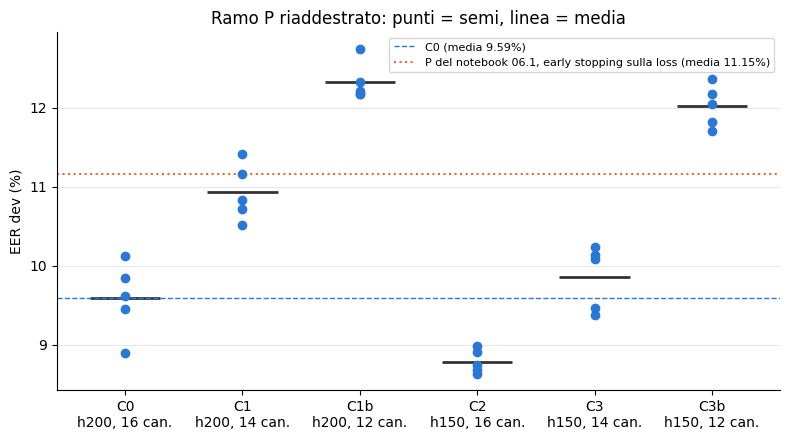


Output: ['__pycache__', 'contrasti_vs_C0.csv', 'eer_per_attacco.csv', 'eer_per_seme.csv', 'eval_metrics.py', 'fig_configurazioni.png', 'modelli', 'preproc_C0.json', 'preproc_C1.json', 'preproc_C1b.json', 'preproc_C2.json', 'preproc_C3.json', 'preproc_C3b.json', 'prosodia_h150', 'punteggi_dev', 'riepilogo.json', 'riepilogo_configurazioni.csv', 'risultati.csv', 'storia.csv', 'verifica.json']


In [11]:
def bootstrap_appaiato(s_a, s_b, n_boot=N_BOOT, seed=0):
    """IC 95% di EER(a) - EER(b) in punti, ricampionando i file del dev per classe (stessi indici)."""
    y = Y["dev"]; g = np.random.default_rng(seed)
    ib, is_ = np.where(y == 1)[0], np.where(y == 0)[0]
    d = []
    for _ in range(n_boot):
        ii = np.concatenate([g.choice(ib, len(ib)), g.choice(is_, len(is_))])
        d.append(compute_eer(y[ii], s_a[ii]) - compute_eer(y[ii], s_b[ii]))
    return np.percentile(100 * np.array(d), [2.5, 97.5])

if "riepilogo" in FASE:
    res = pd.DataFrame(leggi_risultati())
    res = res[res["criterio"] == "eer"].copy()
    res["eer_dev"] *= 100
    cfgs = [c for c in CONFIGURAZIONI if c in set(res["config"])]
    per_seme = res.pivot(index="seed", columns="config", values="eer_dev")[cfgs]
    completi = [c for c in cfgs if per_seme[c].notna().sum() == len(SEMI)]
    assert RIFERIMENTO in completi, "C0 non completo: la regola non è applicabile"
    SC = {(c, sd): np.load(SCO_DIR / f"dev_{c}_s{sd}.npy") for c in completi for sd in SEMI}

    riep = pd.DataFrame({
        "finestre": [CONFIGURAZIONI[c]["finestre"] for c in completi],
        "canali": [len(canali(c)) for c in completi],
        "eer_media_%": [per_seme[c].mean() for c in completi],
        "eer_std_%": [per_seme[c].std() for c in completi],
        "eer_min_%": [per_seme[c].min() for c in completi],
        "eer_max_%": [per_seme[c].max() for c in completi],
        "eer_score_medio_%": [100 * compute_eer(Y["dev"], np.mean([SC[(c, s)] for s in SEMI], 0)) for c in completi],
        "auc_media": [res[res["config"] == c]["auc_dev"].mean() for c in completi],
        "epoca_migliore_media": [res[res["config"] == c]["best_epoch"].mean() for c in completi],
    }, index=completi)
    rif = riep.loc[RIFERIMENTO, "eer_media_%"]
    riep["delta_vs_C0"] = riep["eer_media_%"] - rif
    riep["delta_vs_06_D"] = riep["eer_media_%"] - np.mean([RIF_06[s] for s in SEMI if s in RIF_06])
    riep.to_csv(OUT_DIR / "riepilogo_configurazioni.csv")
    per_seme.to_csv(OUT_DIR / "eer_per_seme.csv")
    print("=== EER dev (%) per seme ==="); display(per_seme.round(2))
    print("=== riepilogo ==="); display(riep.round(3))

    # --- regola di decisione fissata prima dell'esecuzione ---
    candidati = [c for c in completi if c != RIFERIMENTO and riep.loc[c, "eer_media_%"] < rif]
    vincitore = min(candidati, key=lambda c: riep.loc[c, "eer_media_%"]) if candidati else None
    if vincitore is None:
        esito = f"nessuna configurazione scende sotto C0 ({rif:.2f}%): si tiene il ramo P attuale"
        prossimo = "nessuna nuova estrazione su eval"
    else:
        esito = (f"vince {vincitore}: EER medio {riep.loc[vincitore, 'eer_media_%']:.2f}% contro "
                 f"{rif:.2f}% di C0 ({riep.loc[vincitore, 'delta_vs_C0']:+.2f} punti)")
        prossimo = ("estrazione su eval DF 2021 con passo 150 ms (circa 9 h)"
                    if CONFIGURAZIONI[vincitore]["finestre"] == "h150" else
                    "nessuna estrazione: si tolgono i canali dalle feature eval già estratte")
    print("\nDECISIONE:", esito); print("PROSSIMO PASSO:", prossimo)
    mancanti = [c for c in CONFIGURAZIONI if c not in completi]
    if mancanti:
        print("ATTENZIONE: configurazioni non complete, escluse dalla decisione:", mancanti)

    # --- informazioni aggiuntive (non entrano nella regola) ---
    righe = []
    for c in completi:
        if c == RIFERIMENTO:
            continue
        for sd in SEMI:
            lo, hi = bootstrap_appaiato(SC[(c, sd)], SC[(RIFERIMENTO, sd)], seed=sd)
            righe.append({"config": c, "seed": sd, "delta_%": per_seme.loc[sd, c] - per_seme.loc[sd, RIFERIMENTO],
                          "ic_lo": lo, "ic_hi": hi})
    contrasti = pd.DataFrame(righe)
    if len(contrasti):
        contrasti.to_csv(OUT_DIR / "contrasti_vs_C0.csv", index=False)
        sint = contrasti.groupby("config").agg(semi_migliori=("delta_%", lambda x: int((x < 0).sum())),
                                               semi_ic_sotto_zero=("ic_hi", lambda x: int((x < 0).sum())),
                                               semi_ic_sopra_zero=("ic_lo", lambda x: int((x > 0).sum())),
                                               delta_medio=("delta_%", "mean"))
        print("\n=== contrasti appaiati per seme contro C0 (informativi) ==="); display(sint.round(2))

    per_att = pd.DataFrame({c: {a: 100 * compute_eer(Y["dev"][(ATTACK_DEV == "bonafide") | (ATTACK_DEV == a)],
                                                     np.mean([SC[(c, s)] for s in SEMI], 0)[(ATTACK_DEV == "bonafide") | (ATTACK_DEV == a)])
                                for a in sorted(set(ATTACK_DEV) - {"bonafide"})} for c in completi}).T
    per_att.to_csv(OUT_DIR / "eer_per_attacco.csv")
    print("\n=== EER dev (%) per attacco, punteggio medio sui semi ==="); display(per_att.round(2))

    fig, ax = plt.subplots(figsize=(8, 4.5))
    for k, c in enumerate(completi):
        v = per_seme[c].to_numpy()
        ax.scatter(np.full(len(v), k), v, color="#2a78d6", zorder=3)
        ax.hlines(v.mean(), k - 0.3, k + 0.3, color="#333333", lw=2)
    ax.axhline(rif, color="#2a78d6", ls="--", lw=1, label=f"C0 (media {rif:.2f}%)")
    ax.axhline(np.mean(list(RIF_06.values())), color="#eb6834", ls=":", lw=1.5,
               label=f"P del notebook 06.1, early stopping sulla loss (media {np.mean(list(RIF_06.values())):.2f}%)")
    ax.set_xticks(range(len(completi)))
    ax.set_xticklabels([f"{c}\n{CONFIGURAZIONI[c]['finestre']}, {len(canali(c))} can." for c in completi])
    ax.set_ylabel("EER dev (%)"); ax.set_title("Ramo P riaddestrato: punti = semi, linea = media")
    ax.grid(axis="y", alpha=0.3); ax.legend(fontsize=8)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    plt.tight_layout(); plt.savefig(OUT_DIR / "fig_configurazioni.png", dpi=150); plt.show()

    r06 = pd.read_csv(F_RES).query("run == 'R06_D_loss_s0'")
    riepilogo = {
        "domanda": "il ramo P riaddestrato con finestre sovrapposte e/o senza canali di intensità abbassa l'EER sul dev?",
        "configurazioni": {c: {"finestre_s": FINESTRE[CONFIGURAZIONI[c]["finestre"]], "canali": canali(c)}
                           for c in CONFIGURAZIONI},
        "protocollo": {"base": "notebook 06.1, variante D", "differenza": "early stopping, checkpoint e scheduler "
                       "sull'EER ufficiale del dev invece della loss", "max_epochs": MAX_EPOCHS, "patience": PATIENCE,
                       "lr": LR, "batch": BATCH_SIZE, "semi": SEMI, "pos_weight": POS_W},
        "regola": "vince la configurazione con EER medio sui semi più basso tra quelle con EER medio inferiore a C0",
        "eer_dev_%": riep.round(4).reset_index().rename(columns={"index": "config"}).to_dict("records"),
        "riproduzione_06": (None if r06.empty else {"atteso_%": RIF_06[0], "ottenuto_%": 100 * float(r06["eer_dev"].iloc[0])}),
        "decisione": esito, "prossimo_passo": prossimo, "vincitore": vincitore,
        "eer_function": {"source": EVAL_METRICS_URL, "sha256": EVAL_METRICS_SHA256},
        "limiti": ["il dev serve sia per l'early stopping sia per la scelta della configurazione: EER dev del vincitore ottimista",
                   "la regola usa solo la media: una differenza inferiore alla variabilità fra semi può dipendere dal caso "
                   "(vedi contrasti_vs_C0.csv)",
                   "la scelta dei canali di intensità deriva dall'ablazione su eval (notebook 15)",
                   "il dev 2019 contiene gli stessi tipi di attacco del train: un guadagno sul dev può non trasferirsi a DF 2021"]}
    (OUT_DIR / "riepilogo.json").write_text(json.dumps(riepilogo, indent=2, default=float))
    print("\nOutput:", sorted(p.name for p in OUT_DIR.iterdir()))